# 7. Modelling con un target binario

**1. Crear target binario**

In [65]:
df_bin = df_final.copy()

# Variable objetivo binaria: tercil superior de tasa_x1000 por año
df_bin['riesgo_bin'] = df_bin.groupby('año')['tasa_x1000'].transform(
    lambda x: (x >= x.quantile(2/3)).map({True: 'prioritario', False: 'no_prioritario'})
)

# Verificar distribución
print("=== TARGET BINARIO ===")
vc  = df_bin['riesgo_bin'].value_counts()
vcp = df_bin['riesgo_bin'].value_counts(normalize=True) * 100
for cat in ['no_prioritario', 'prioritario']:
    barra = '█' * int(vcp[cat] / 2)
    print(f"  {cat:<20} {vc[cat]:>5,}  ({vcp[cat]:.1f}%)  {barra}")
print(f"\nDesbalance: {vc.max()/vc.min():.2f}:1")

# Face validity
print("\nTop 10 municipios por frecuencia de 'prioritario':")
top_prio = (
    df_bin[df_bin['riesgo_bin'] == 'prioritario']
    .groupby('cod_mun')
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print(top_prio)



=== TARGET BINARIO ===
  no_prioritario       4,213  (66.6%)  █████████████████████████████████
  prioritario          2,117  (33.4%)  ████████████████

Desbalance: 1.99:1

Top 10 municipios por frecuencia de 'prioritario':
cod_mun
99773    7
86568    7
99001    7
85263    7
85250    7
81001    7
81736    7
81794    7
85001    7
44847    7
dtype: int64


**2. Features y split**

In [66]:
#Features del modelo
FEATURES_AVANZADO = FEATURES_TOPO_CLIMA + FEATURES_LAG + [
    'dist_capital_dpto',
    'dist_bogota',
    'dist_ciudad_cercana',
    'MDM',
    'Componente de gestión',
    'Componente de resultados',
]

FEATURES_AVANZADO_DISP = [f for f in FEATURES_AVANZADO if f in df_bin.columns]
faltantes = [f for f in FEATURES_AVANZADO if f not in df_bin.columns]
if faltantes:
    print(f"⚠ No encontradas en df_bin: {faltantes}")
print(f"✓ Features avanzado: {len(FEATURES_AVANZADO_DISP)} de {len(FEATURES_AVANZADO)} esperados")

#Codificación del target
ORDEN_BIN = ['no_prioritario', 'prioritario']
le_bin = LabelEncoder()
le_bin.classes_ = np.array(ORDEN_BIN)
joblib.dump(le_bin, 'label_encoder.pkl')  # para interpretar predicciones en la API

# Split train/test

def preparar_split(features_disp):
    df_clean = df_bin[features_disp + ['riesgo_bin', 'cod_mun']].dropna().copy()
    df_clean['target'] = le_bin.transform(df_clean['riesgo_bin'])
    train = df_clean[df_clean['año'].isin(TRAIN_AÑOS)]
    test  = df_clean[df_clean['año'].isin(TEST_AÑOS)]
    X_tr, y_tr = train[features_disp], train['target']
    X_te, y_te = test[features_disp],  test['target']
    grupos = train['cod_mun']
    return X_tr, y_tr, X_te, y_te, grupos, train, test

X_tr, y_tr, X_te, y_te, grupos, train, test = preparar_split(FEATURES_AVANZADO_DISP)

✓ Features avanzado: 36 de 36 esperados


**3. Entrenar modelos**

In [67]:
resultados_bin = {}

# Asegurarse de que la columna 'año' sea de tipo entero para XGBoost
X_tr['año'] = X_tr['año'].astype(int)
X_te['año'] = X_te['año'].astype(int)

# ── Baseline: Regresión Logística ──
pipe_lr = Pipeline([
    ('sc', StandardScaler()),
    ('m',  LogisticRegression(C=0.1, penalty='l2', max_iter=2000, random_state=42))
])
cv_lr = cross_val_score(pipe_lr, X_tr, y_tr, cv=cv, groups=grupos,
                         scoring='f1', n_jobs=-1)
pipe_lr.fit(X_tr, y_tr)
y_pred_lr = pipe_lr.predict(X_te)
resultados_bin['Logística'] = {
    'cv_f1': cv_lr.mean(), 'cv_std': cv_lr.std(),
    'f1':    f1_score(y_te, y_pred_lr),
    'auc':   roc_auc_score(y_te, pipe_lr.predict_proba(X_te)[:,1]),
    'preds': y_pred_lr,
    'proba': pipe_lr.predict_proba(X_te)[:,1],
}

# ── Random Forest ──
rf_bin = RandomForestClassifier(n_estimators=300, max_depth=8,
                                  min_samples_leaf=20, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
cv_rf = cross_val_score(rf_bin, X_tr, y_tr, cv=cv, groups=grupos,
                         scoring='f1', n_jobs=-1)
rf_bin.fit(X_tr, y_tr)
y_pred_rf = rf_bin.predict(X_te)
resultados_bin['Random Forest'] = {
    'cv_f1': cv_rf.mean(), 'cv_std': cv_rf.std(),
    'f1':    f1_score(y_te, y_pred_rf),
    'auc':   roc_auc_score(y_te, rf_bin.predict_proba(X_te)[:,1]),
    'preds': y_pred_rf,
    'proba': rf_bin.predict_proba(X_te)[:,1],
}

# ── XGBoost ──
xgb_bin = XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.04,
    subsample=0.8, colsample_bytree=0.7,
    min_child_weight=10, reg_alpha=0.5, reg_lambda=2.0,
    scale_pos_weight=1,  # 1 porque está balanceado
    eval_metric='logloss', use_label_encoder=False,
    random_state=42, n_jobs=-1
)
cv_xgb = cross_val_score(xgb_bin, X_tr, y_tr, cv=cv, groups=grupos,
                          scoring='f1', n_jobs=-1)
xgb_bin.fit(X_tr, y_tr, verbose=False)
y_pred_xgb = xgb_bin.predict(X_te)
resultados_bin['XGBoost'] = {
    'cv_f1': cv_xgb.mean(), 'cv_std': cv_xgb.std(),
    'f1':    f1_score(y_te, y_pred_xgb),
    'auc':   roc_auc_score(y_te, xgb_bin.predict_proba(X_te)[:,1]),
    'preds': y_pred_xgb,
    'proba': xgb_bin.predict_proba(X_te)[:,1],
}

print("=" * 62)
print("  COMPARACIÓN — CLASIFICACIÓN BINARIA")
print("=" * 62)
print(f"\n  {'Modelo':<18} {'CV F1':>8} {'±':>6} {'Test F1':>8} {'AUC-ROC':>8}")
print(f"  {'-'*52}")
for nombre, r in resultados_bin.items():
    print(f"  {nombre:<18} {r['cv_f1']:>8.3f} {r['cv_std']:>6.3f} "
          f"{r['f1']:>8.3f} {r['auc']:>8.3f}")

# Seleccionar mejor
mejor_nombre = max(resultados_bin, key=lambda k: resultados_bin[k]['f1'])
mejor        = resultados_bin[mejor_nombre]
print(f"\n  Mejor modelo: {mejor_nombre}  (F1={mejor['f1']:.3f})")
print(f"\n  Reporte {mejor_nombre}:")
print(classification_report(y_te, mejor['preds'],
                             target_names=ORDEN_BIN, digits=3))

  COMPARACIÓN — CLASIFICACIÓN BINARIA

  Modelo                CV F1      ±  Test F1  AUC-ROC
  ----------------------------------------------------
  Logística             0.565  0.038    0.638    0.797
  Random Forest         0.636  0.020    0.647    0.812
  XGBoost               0.579  0.029    0.630    0.796

  Mejor modelo: Random Forest  (F1=0.647)

  Reporte Random Forest:
                precision    recall  f1-score   support

no_prioritario      0.844     0.692     0.760      1025
   prioritario      0.565     0.758     0.647       541

      accuracy                          0.715      1566
     macro avg      0.704     0.725     0.704      1566
  weighted avg      0.748     0.715     0.721      1566



In [68]:
X_te.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1566 entries, 5 to 6329
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   analfabetismo                  1566 non-null   float64
 1   bajo_logro_educativo           1566 non-null   float64
 2   barreras_primera_infancia      1566 non-null   float64
 3   barreras_acceso_salud          1566 non-null   float64
 4   tasa_dependencia               1566 non-null   float64
 5   hacinamiento_critico           1566 non-null   float64
 6   inadec_eliminacion_excretas    1566 non-null   float64
 7   inasistencia_escolar           1566 non-null   float64
 8   inadec_paredes                 1566 non-null   float64
 9   inadec_pisos                   1566 non-null   float64
 10  rezago_escolar                 1566 non-null   float64
 11  sin_agua_mejorada              1566 non-null   float64
 12  sin_aseguramiento_salud        1566 non-null   float6

,Modelo,"F1 (CV, 5 folds)",± Desv. estándar,"F1 (Test, clase prioritaria)",AUC-ROC (Test)
0,Logística,0.565,0.038,0.638,0.797
1,Random Forest ✓,0.636,0.020,0.647,0.812
2,XGBoost,0.579,0.029,0.630,0.796


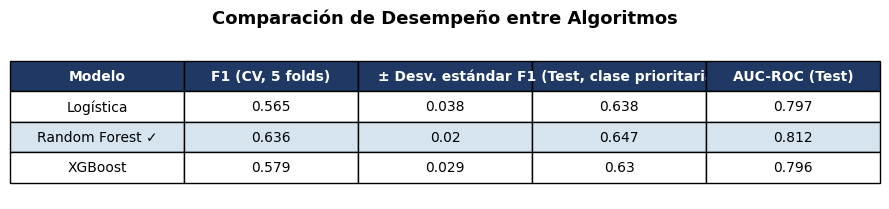

In [69]:
# ── 1. Construir la tabla resumen ──
tabla_resumen = pd.DataFrame({
    'Modelo': list(resultados_bin.keys()),
    'F1 (CV, 5 folds)': [r['cv_f1'] for r in resultados_bin.values()],
    '± Desv. estándar': [r['cv_std'] for r in resultados_bin.values()],
    'F1 (Test, clase prioritaria)': [r['f1'] for r in resultados_bin.values()],
    'AUC-ROC (Test)': [r['auc'] for r in resultados_bin.values()],
}).round(3)

# Marcar el modelo seleccionado
tabla_resumen['Modelo'] = tabla_resumen['Modelo'].apply(
    lambda m: f"{m} ✓" if m == mejor_nombre else m
)

display(tabla_resumen)

# ── 2. Renderizar como imagen para el documento ──
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.axis('off')

tabla = ax.table(
    cellText=tabla_resumen.values,
    colLabels=tabla_resumen.columns,
    cellLoc='center',
    loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 2)

best_idx = tabla_resumen.index[tabla_resumen['Modelo'].str.endswith('✓')][0]

for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1f3864')
        cell.set_text_props(color='white', weight='bold')
    elif row - 1 == best_idx:
        cell.set_facecolor('#d6e4f0')  # resalta la fila del modelo definitivo

plt.title('Comparación de Desempeño entre Algoritmos', fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.savefig('tabla_comparacion_modelos.png', dpi=200, bbox_inches='tight')
plt.show()

,Modelo,F1-macro (Test),Precisión macro,Recall macro,Exactitud,AUC-ROC (Test)
0,Logística,0.710,0.706,0.720,0.727,0.797
1,Random Forest ✓,0.704,0.704,0.725,0.715,0.812
2,XGBoost,0.720,0.723,0.718,0.750,0.796


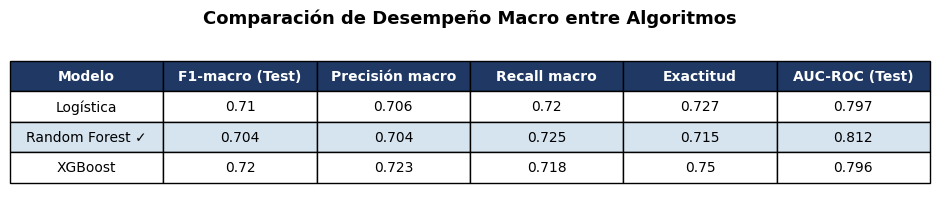

In [70]:
# ── 1. Calcular métricas macro para cada modelo ──
for nombre, r in resultados_bin.items():
    r['f1_macro']        = f1_score(y_te, r['preds'], average='macro')
    r['precision_macro'] = precision_score(y_te, r['preds'], average='macro')
    r['recall_macro']    = recall_score(y_te, r['preds'], average='macro')
    r['accuracy']        = accuracy_score(y_te, r['preds'])

# ── 2. Construir la tabla resumen ──
tabla_macro = pd.DataFrame({
    'Modelo':          list(resultados_bin.keys()),
    'F1-macro (Test)': [r['f1_macro']        for r in resultados_bin.values()],
    'Precisión macro': [r['precision_macro'] for r in resultados_bin.values()],
    'Recall macro':    [r['recall_macro']    for r in resultados_bin.values()],
    'Exactitud':       [r['accuracy']        for r in resultados_bin.values()],
    'AUC-ROC (Test)':  [r['auc']             for r in resultados_bin.values()],
}).round(3)

# Marcar el modelo definitivo (ya seleccionado antes como 'mejor_nombre')
tabla_macro['Modelo'] = tabla_macro['Modelo'].apply(
    lambda m: f"{m} ✓" if m == mejor_nombre else m
)

display(tabla_macro)

# ── 3. Renderizar como imagen para el documento ──
fig, ax = plt.subplots(figsize=(9.5, 2.2))
ax.axis('off')

tabla = ax.table(
    cellText=tabla_macro.values,
    colLabels=tabla_macro.columns,
    cellLoc='center',
    loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 2)

best_idx = tabla_macro.index[tabla_macro['Modelo'].str.endswith('✓')][0]

for (row, col), cell in tabla.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1f3864')
        cell.set_text_props(color='white', weight='bold')
    elif row - 1 == best_idx:
        cell.set_facecolor('#d6e4f0')

plt.title('Comparación de Desempeño Macro entre Algoritmos', fontsize=13, weight='bold', pad=15)
plt.tight_layout()
plt.savefig('tabla_comparacion_macro.png', dpi=200, bbox_inches='tight')
plt.show()

**4. Curvas ROC, precisión, recall y matrices de confusión**

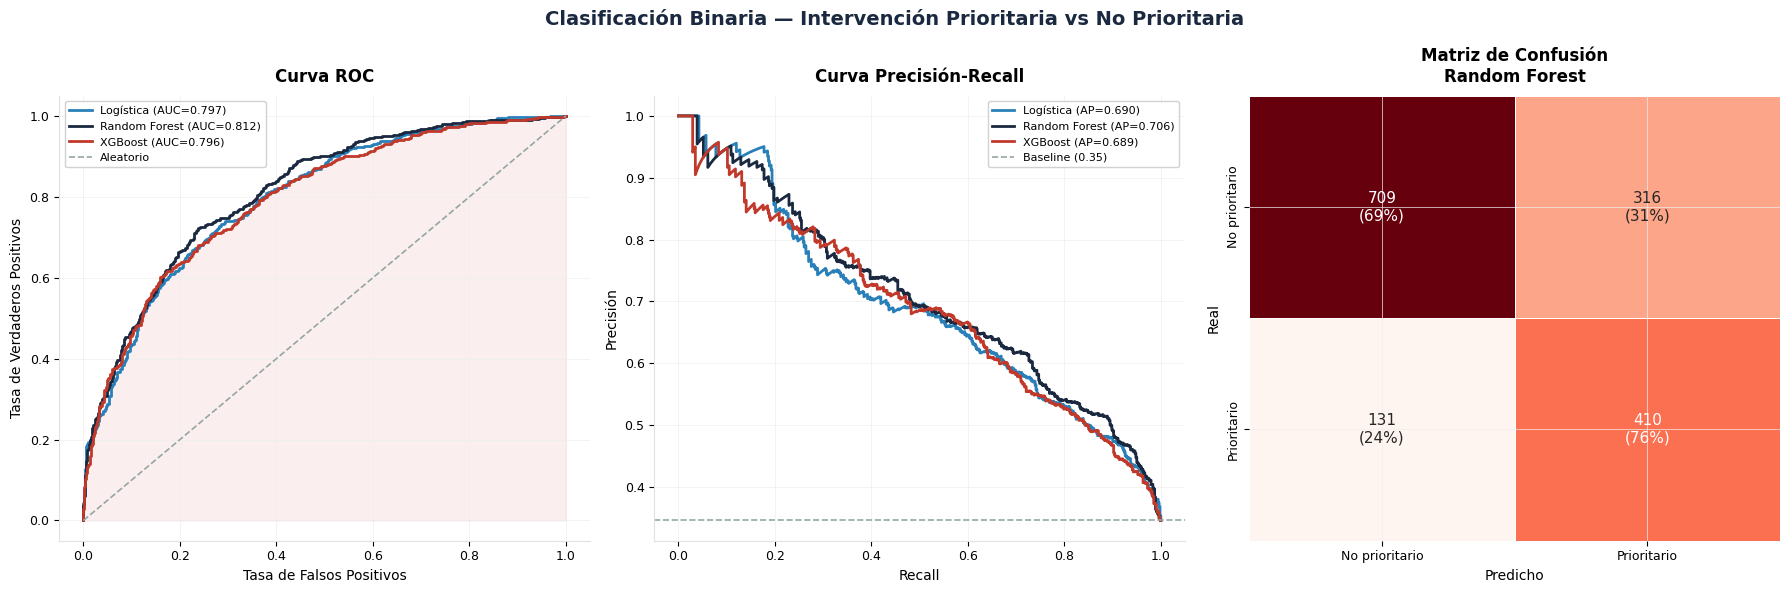

In [71]:
C['prioritario']    = '#c0392b'
C['no_prioritario'] = '#27ae60'
ORDEN_BIN = ['no_prioritario', 'prioritario']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Clasificación Binaria — Intervención Prioritaria vs No Prioritaria',
             fontsize=14, fontweight='bold', color=C['primary'])

colores_mod = {'Logística': C['accent'], 'Random Forest': C['primary'], 'XGBoost': C['prioritario']}

# 4.1 Curva ROC
for nombre, r in resultados_bin.items():
    fpr, tpr, _ = roc_curve(y_te, r['proba'])
    axes[0].plot(fpr, tpr, lw=2, color=colores_mod[nombre],
                 label=f"{nombre} (AUC={r['auc']:.3f})")
axes[0].plot([0,1],[0,1], color=C['mid'], ls='--', lw=1.2, label='Aleatorio')
axes[0].fill_between(*roc_curve(y_te, resultados_bin['XGBoost']['proba'])[:2],
                      alpha=0.08, color=C['prioritario'])
axes[0].set_title('Curva ROC')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0].legend(fontsize=8)

# 4.2 Curva Precisión-Recall
for nombre, r in resultados_bin.items():
    prec, rec, _ = precision_recall_curve(y_te, r['proba'])
    ap = average_precision_score(y_te, r['proba'])
    axes[1].plot(rec, prec, lw=2, color=colores_mod[nombre],
                 label=f"{nombre} (AP={ap:.3f})")
baseline_pr = y_te.mean()
axes[1].axhline(baseline_pr, color=C['mid'], ls='--', lw=1.2,
                label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_title('Curva Precisión-Recall')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precisión')
axes[1].legend(fontsize=8)

# 4.3 Matriz de confusión del mejor modelo
cm = confusion_matrix(y_te, mejor['preds'])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f'{v}\n({p:.0f}%)'
                   for v, p in zip(row_v, row_p)]
                  for row_v, row_p in zip(cm, cm_pct)])
import seaborn as sns
sns.heatmap(cm, annot=annot, fmt='', ax=axes[2],
            cmap='Reds', linewidths=0.5, linecolor='white',
            xticklabels=['No prioritario','Prioritario'],
            yticklabels=['No prioritario','Prioritario'],
            cbar=False, annot_kws={'size':11})
axes[2].set_title(f'Matriz de Confusión\n{mejor_nombre}')
axes[2].set_xlabel('Predicho'); axes[2].set_ylabel('Real')

plt.tight_layout()
plt.savefig('binario_01_evaluacion.png', dpi=150, bbox_inches='tight')
plt.show()